# K-Means Clustering — Google Colab

**Goal:** Group similar customers into **clusters** using **K-Means** — an **unsupervised** algorithm (no target label required).

| Example | Feature(s) (X) | Dataset |
|---------|----------------|---------|
| **Example 1** | Age, Annual_Income | `../Datasets/mall_customers.csv` |
| **Example 2** | Income, Spending_Score, Age, Num_Purchases | `../Datasets/customer_segments.csv` |

| Phase | Topic | Cells |
|-------|-------|-------|
| Phase 0 | Setup | Install & Imports |
| — | Algorithm Guide | Centroids, inertia, elbow, silhouette |
| Phase 1 | Data Pre-processing | Load → Cleaning → Encoding → Prepare X |
| Phase 2 | Algorithm | Choose K → Train → Predict → Visualize → Evaluate |

> **Run:** Runtime → Run all (or Ctrl+F9)

> **Note:** Clustering is **unsupervised** — there is **no y (target)** column.

---
# Algorithm Guide — K-Means Clustering

## What is Clustering?

**Clustering** groups similar data points together **without labels**. The algorithm discovers hidden patterns in the data.

| Learning type | Has labels? | Example |
|---------------|-------------|---------|
| **Supervised** | Yes (y) | Classification, Regression |
| **Unsupervised** | **No** | **K-Means Clustering** |

## What is K-Means?

**K-Means** partitions data into **K clusters** by minimizing the distance from each point to its cluster **centroid** (center).

| Term | Meaning |
|------|---------|
| **K** | Number of clusters (you choose) |
| **Centroid** | Mean of all points in a cluster |
| **Assignment** | Each point belongs to the **nearest** centroid |
| **Iteration** | Recompute centroids → reassign → repeat until stable |

## K-Means Algorithm (Step by Step)

| Step | Action |
|------|--------|
| 1 | Choose **K** (number of clusters) |
| 2 | Initialize **K centroids** randomly |
| 3 | Assign each point to the **nearest** centroid |
| 4 | Update each centroid = **mean** of assigned points |
| 5 | Repeat steps 3–4 until centroids **stop moving** |

## Objective Function — Inertia

**Inertia** = sum of squared distances from each point to its cluster centroid.

`Inertia = Σ ||xᵢ − μ_c||²`

| Inertia | Meaning |
|---------|---------|
| **Lower** | Tighter, more compact clusters |
| **K = n** | Inertia = 0 (each point is its own cluster — useless) |

## Choosing K

| Method | How it works |
|--------|--------------|
| **Elbow Method** | Plot K vs inertia — look for the **elbow** (diminishing returns) |
| **Silhouette Score** | Measures how well each point fits its cluster (−1 to **1**, higher = better) |
| **Domain knowledge** | Business decides (e.g. 5 customer segments) |

## Feature Scaling — Required!

K-Means uses **Euclidean distance**. Features with larger scale dominate → always apply **`StandardScaler`** before K-Means.

## Key Hyperparameters (sklearn)

| Parameter | Role |
|-----------|------|
| `n_clusters` | **K** — number of clusters |
| `init` | Centroid initialization (`'k-means++'` default — smart start) |
| `n_init` | Number of times to run with different seeds (pick best inertia) |
| `max_iter` | Maximum iterations per run |
| `random_state` | Reproducible results |

## K-Means vs Classification

| | K-Means | K-NN Classification |
|---|---------|---------------------|
| Type | **Unsupervised** | Supervised |
| Labels | **Not needed** | Required |
| Output | Cluster ID (0, 1, …, K−1) | Class label |
| Scaling | **Required** | Required |

## What the Student Must Remember

1. K-Means = **unsupervised** — no target column.
2. **Always scale features** before clustering.
3. Choose **K** using the **elbow method** and **silhouette score**.
4. Output = **cluster label** for each row (`predict` or `fit_predict`).
5. Centroids = **mean** of points in each cluster.

## Phase 0 — Cell 0: Install Libraries

Google Colab usually includes most libraries. This cell ensures required packages are available.

**What this cell does:** Installs scikit-learn, pandas, matplotlib, numpy, and seaborn quietly.

In [75]:
# Install into the same Python as this notebook kernel (avoids pip/kernel mismatch)
import sys
!{sys.executable} -m pip install -q scikit-learn pandas matplotlib numpy


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip


## Phase 0 — Cell 1: Import Libraries

Import libraries for preprocessing, K-Means clustering, and evaluation.

**What this cell does:** Loads numpy, pandas, matplotlib, sklearn KMeans, StandardScaler, and metrics.

In [76]:
# --- Import libraries ---
import numpy as np              # Numerical operations and arrays
import pandas as pd             # Load and manipulate tabular data
import matplotlib.pyplot as plt # Create charts and plots

from sklearn.impute import SimpleImputer                   # Fill missing values
from sklearn.preprocessing import StandardScaler           # Feature scaling (required for K-Means)
from sklearn.cluster import KMeans                         # K-Means clustering algorithm
from sklearn.metrics import silhouette_score, silhouette_samples  # Clustering evaluation

plt.rcParams['figure.figsize'] = (10, 6)  # Default plot size: width=10, height=6 inches
plt.style.use('seaborn-v0_8-whitegrid')   # Clean white background with grid lines
np.random.seed(42)                          # Fix random seed for reproducible results

print('Libraries ready')                      # Confirm all imports loaded successfully

Libraries ready


---
# Example 1: Mall Customers — K-Means Clustering

Segment mall customers by **Age** and **Annual Income** into **K groups** for targeted marketing.

| Column | Role | Description |
|--------|------|-------------|
| `Age` | Feature (X₁) | Customer age in years |
| `Annual_Income` | Feature (X₂) | Annual income in USD |
| `Spending_Score` | Info only (not used for clustering) | Spending score 1–100 — for reference |

**File:** `../Datasets/mall_customers.csv`

**Clustering uses:** Age + Annual_Income only (2 features for easy visualization).

---
# Phase 1: Data Pre-processing

Prepare features for clustering — **no target column** in unsupervised learning.

## Example 1 — Cell 1: Load and Explore Data

Load the CSV file and perform initial exploration (head, info, describe, shape).

**What this cell does:** Reads `../Datasets/mall_customers.csv` and displays basic statistics.

In [77]:
# Step 1) Load dataset
dataset = pd.read_csv('../Datasets/mall_customers.csv')  # Read CSV into a DataFrame

FEATURE_COLS = ['Age', 'Annual_Income']  # Features used for clustering
INFO_COL = 'Spending_Score'              # Extra column — not used for K-Means (reference only)

print('First 5 rows:')
display(dataset.head())

print('\nDataset info:')
dataset.info()

print('\nStatistical summary:')
display(dataset.describe())

print(f'\nShape: {dataset.shape[0]} rows x {dataset.shape[1]} columns')
print('Unsupervised learning — no target (y) column.')

First 5 rows:


,Age,Annual_Income,Spending_Score
0,22.5,25908,28.2
1,19.3,21371,32.9
2,23.2,19075,41.8
3,27.6,17591,25.9
4,18.8,15000,23.5



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             200 non-null    float64
 1   Annual_Income   200 non-null    int64  
 2   Spending_Score  200 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 4.8 KB

Statistical summary:


,Age,Annual_Income,Spending_Score
count,200.000000,200.000000,200.000000
mean,40.034000,54658.170000,50.106500
std,16.476481,30613.957205,23.639021
min,18.000000,15000.000000,3.800000
25%,23.025000,22067.250000,28.475000
50%,41.000000,60566.500000,49.400000
75%,55.700000,83472.500000,72.700000
max,69.500000,107064.000000,96.700000



Shape: 200 rows x 3 columns
Unsupervised learning — no target (y) column.


## Example 1 — Cell 2: Data Cleaning (Handling Missing Values)

Check missing values, remove duplicates, and apply imputation if needed.

**What this cell does:** Cleans the dataset before clustering.

In [78]:
# Step 2) Data cleaning

print('Missing values per column:')
print(dataset.isnull().sum())

rows_before = len(dataset)
dataset = dataset.drop_duplicates().reset_index(drop=True)
rows_after = len(dataset)
print(f'\nDuplicates removed: {rows_before - rows_after}')

num_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
if dataset.isnull().sum().sum() > 0:
    dataset[num_cols] = imputer.fit_transform(dataset[num_cols])
    print('Missing values imputed with mean')
else:
    print('No missing values — imputer not applied')

print(f'\nRows after cleaning: {rows_after}')

Missing values per column:
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

Duplicates removed: 0
No missing values — imputer not applied

Rows after cleaning: 200


## Example 1 — Cell 3: Categorical Data Encoding

All clustering features are numeric — encoding is skipped.

**What this cell does:** Confirms no categorical encoding is needed.

In [79]:
# Step 3) Categorical encoding

cat_cols = dataset.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    print(f'Categorical columns found: {cat_cols}')
else:
    print('No categorical columns — encoding skipped.')
    print(f'Feature columns for clustering: {FEATURE_COLS}')

No categorical columns — encoding skipped.
Feature columns for clustering: ['Age', 'Annual_Income']


## Example 1 — Cell 4: Prepare Features and Scale

Define **X** (features only) and apply **StandardScaler** — required for K-Means.

**What this cell does:** Creates the feature matrix and scales it for distance-based clustering.

In [80]:
# Step 4) Prepare and scale features (no train/test split — clustering uses all data)

X = dataset[FEATURE_COLS].values  # Feature matrix only — no y

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Scale to mean=0, std=1

print(f'X shape: {X.shape}')
print(f'X_scaled shape: {X_scaled.shape}')
print('Features scaled with StandardScaler — ready for K-Means.')

X shape: (200, 2)
X_scaled shape: (200, 2)
Features scaled with StandardScaler — ready for K-Means.


> **Note:** K-Means uses **Euclidean distance** — **StandardScaler is mandatory** when Age and Income have different units.

---
# Phase 2: K-Means — Mall Customers

Choose **K** with the elbow method, then fit K-Means and visualize clusters.

## Example 1 — Cell 5: Choose K (Elbow Method + Silhouette)

Try K = 1 to 10 — plot **inertia** (elbow) and **silhouette score** to pick the best K.

**What this cell does:** Finds optimal K before training the final model.

Best K (highest silhouette): 4
Silhouette at K=4: 0.6243


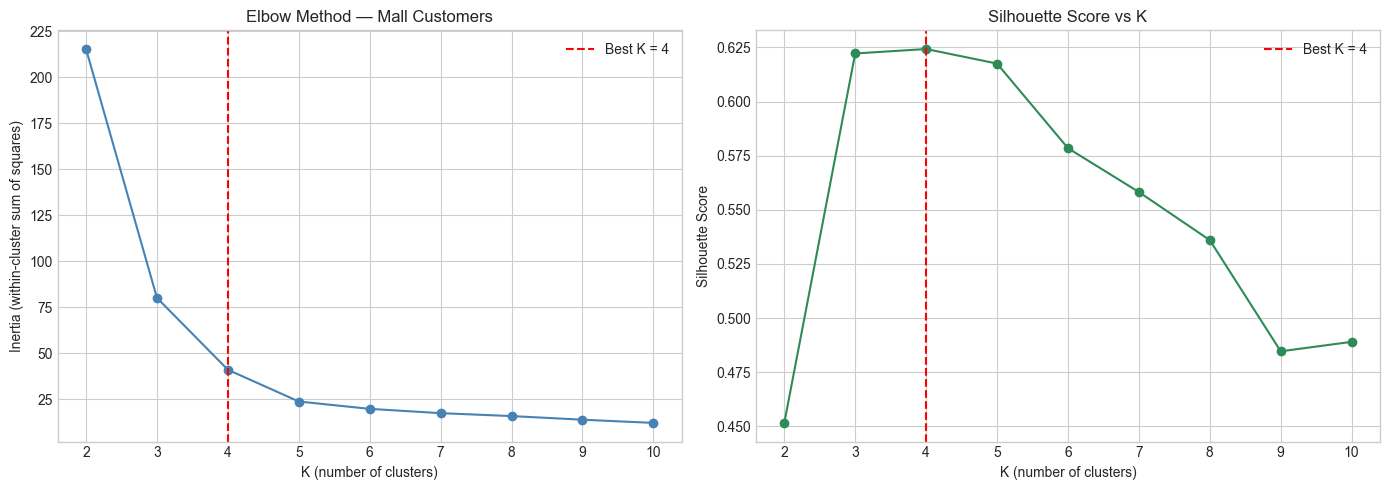

In [81]:
# Step 5) Choose K — elbow method and silhouette score

K_range = range(2, 11)  # K must be at least 2 for meaningful clusters
inertias = []
silhouettes = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))

best_k = list(K_range)[np.argmax(silhouettes)]  # K with highest silhouette score
print(f'Best K (highest silhouette): {best_k}')
print(f'Silhouette at K={best_k}: {max(silhouettes):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, marker='o', color='steelblue')
axes[0].axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
axes[0].set_xlabel('K (number of clusters)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow Method — Mall Customers')
axes[0].legend()

axes[1].plot(list(K_range), silhouettes, marker='o', color='seagreen')
axes[1].axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
axes[1].set_xlabel('K (number of clusters)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K')
axes[1].legend()

plt.tight_layout()
plt.show()

## Example 1 — Cell 6: Train K-Means and Assign Clusters

Fit K-Means with the chosen **K** and assign each customer a cluster label.

**What this cell does:** Trains the model and adds cluster labels to the dataset.

In [82]:
# Step 6) Train K-Means and assign cluster labels

kmeans = KMeans(
    n_clusters=best_k,     # Number of clusters from step 5
    init='k-means++',      # Smart centroid initialization
    n_init=10,             # Run 10 times — keep best inertia
    random_state=42
)

cluster_labels = kmeans.fit_predict(X_scaled)  # Fit and assign cluster ID (0 to K-1)

dataset['Cluster'] = cluster_labels  # Add cluster column to DataFrame

print(f'K-Means trained with K = {best_k}')
print(f'Inertia: {kmeans.inertia_:.2f}')
print(f'\nCustomers per cluster:')
print(dataset['Cluster'].value_counts().sort_index())

print('\nCluster centers (scaled space):')
print(kmeans.cluster_centers_.round(3))

K-Means trained with K = 4
Inertia: 41.03

Customers per cluster:
Cluster
0    69
1    40
2    40
3    51
Name: count, dtype: int64

Cluster centers (scaled space):
[[-0.599  1.083]
 [ 1.167 -1.153]
 [-1.197 -1.098]
 [ 0.834  0.3  ]]


## Example 1 — Cell 7: Visualization

Plot customers colored by **cluster** with **centroids** marked.

**What this cell does:** Visualizes K-Means segments in the Age–Income plane.

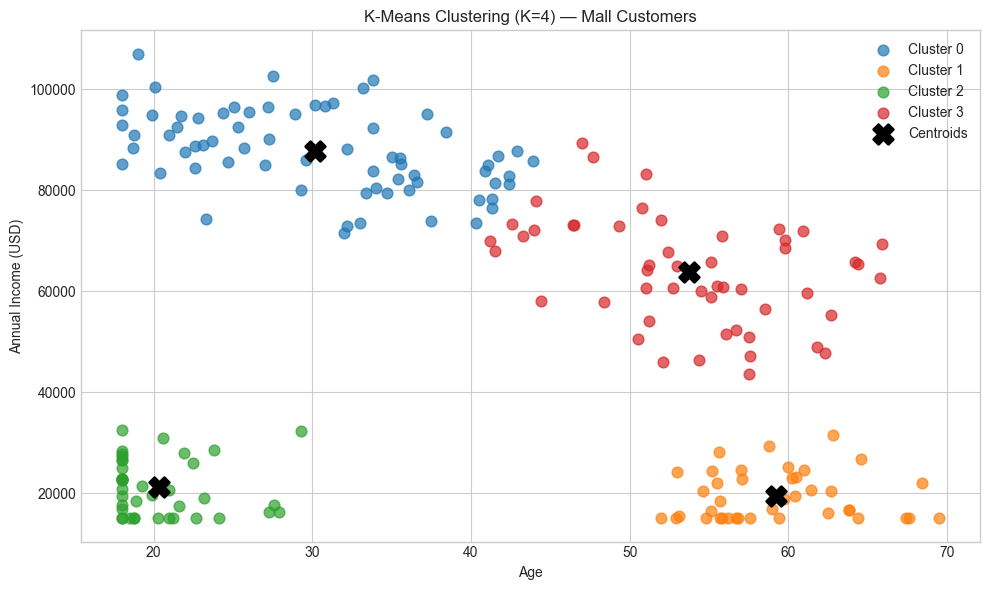

In [83]:
# Step 7) Visualization — scatter plot with centroids

centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)  # Back to original scale

plt.figure(figsize=(10, 6))
palette = [plt.cm.tab10(i % 10) for i in range(best_k)]

for c in range(best_k):
    mask = cluster_labels == c
    plt.scatter(
        X[mask, 0], X[mask, 1],
        c=[palette[c]], label=f'Cluster {c}', alpha=0.7, s=60
    )

plt.scatter(
    centroids_original[:, 0], centroids_original[:, 1],
    c='black', marker='X', s=200, linewidths=2, label='Centroids', zorder=5
)

plt.xlabel('Age')
plt.ylabel('Annual Income (USD)')
plt.title(f'K-Means Clustering (K={best_k}) — Mall Customers')
plt.legend()
plt.tight_layout()
plt.show()

## Example 1 — Cell 8: Evaluation

Evaluate clustering quality with **Silhouette Score** and **Inertia**.

**What this cell does:** Computes unsupervised clustering metrics (not Accuracy — no labels).

In [84]:
# Step 8) Evaluation — clustering metrics (unsupervised)

sil_avg = silhouette_score(X_scaled, cluster_labels)  # Overall silhouette (−1 to 1)
sil_samples = silhouette_samples(X_scaled, cluster_labels)  # Per-point silhouette

results = pd.DataFrame({
    'Metric': ['Inertia', 'Silhouette Score', 'Number of Clusters'],
    'Value': [kmeans.inertia_, sil_avg, best_k],
    'Description': [
        'Within-cluster sum of squared distances (lower = tighter)',
        'Cluster quality: 1 = perfect, 0 = overlapping, <0 = wrong cluster',
        'K chosen by silhouette score'
    ]
})

display(results.round(4))

print(f'\nExample 1 Silhouette Score = {sil_avg:.4f}')
print('(No Accuracy — clustering is unsupervised, no true labels to compare)')

,Metric,Value,Description
0,Inertia,41.0285,Within-cluster sum of squared distances (lower...
1,Silhouette Score,0.6243,"Cluster quality: 1 = perfect, 0 = overlapping,..."
2,Number of Clusters,4.0000,K chosen by silhouette score



Example 1 Silhouette Score = 0.6243
(No Accuracy — clustering is unsupervised, no true labels to compare)


## Why does K-Means work for Mall Customers?

| # | Reason | Explanation |
|---|--------|-------------|
| 1 | **Natural segments** | Age and Income form visible groups in 2D space |
| 2 | **Spherical clusters** | K-Means assumes round clusters — works well here |
| 3 | **Scaling** | Income (~50k) vs Age (~40) — StandardScaler makes distance fair |
| 4 | **Marketing use** | Each cluster = a customer segment for targeted campaigns |
| 5 | **Elbow + silhouette** | Data-driven choice of K instead of guessing |

> **Summary:** K-Means discovers **customer segments** without needing a "Purchased" label.

## Understanding Clustering Metrics — Example 1

| Metric | Meaning |
|--------|---------|
| **Inertia** | How compact clusters are — compare across K (elbow) |
| **Silhouette** | How well-separated clusters are — **> 0.5** = reasonable |
| **No Accuracy** | Unsupervised — no y to compare predictions against |

> **Tip:** Color points by `Spending_Score` separately to see if clusters match spending behavior.

---
# Example 2: Customer Segments — K-Means (Multi-Feature)

Segment customers using **four features** — income, spending, age, and purchase frequency.

| Column | Role | Description |
|--------|------|-------------|
| `Income` | Feature (X₁) | Annual income in USD |
| `Spending_Score` | Feature (X₂) | Spending score 1–100 |
| `Age` | Feature (X₃) | Customer age |
| `Num_Purchases` | Feature (X₄) | Number of purchases per year |

**File:** `../Datasets/customer_segments.csv`

## Example 2 — Cell 1: Load and Explore Data

Load the customer segments CSV and inspect the data.

**What this cell does:** Reads `../Datasets/customer_segments.csv` and displays basic statistics.

In [85]:
# Step 1) Load dataset
dataset = pd.read_csv('../Datasets/customer_segments.csv')

FEATURE_COLS = ['Income', 'Spending_Score', 'Age', 'Num_Purchases']

print('First 5 rows:')
display(dataset.head())

print('\nDataset info:')
dataset.info()

print('\nStatistical summary:')
display(dataset.describe())

print(f'\nShape: {dataset.shape[0]} rows x {dataset.shape[1]} columns')

First 5 rows:


,Income,Spending_Score,Age,Num_Purchases
0,41055,1.0,30.2,2
1,45845,1.0,21.9,3
2,36444,36.4,23.8,6
3,35375,28.8,33.1,4
4,55309,15.2,21.5,2



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Income          180 non-null    int64  
 1   Spending_Score  180 non-null    float64
 2   Age             180 non-null    float64
 3   Num_Purchases   180 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 5.8 KB

Statistical summary:


,Income,Spending_Score,Age,Num_Purchases
count,180.000000,180.000000,180.000000,180.000000
mean,76400.844444,34.961111,39.136667,6.227778
std,34326.142874,20.828248,11.575431,4.395059
min,20000.000000,1.000000,18.000000,0.000000
25%,45791.500000,17.925000,30.025000,3.000000
50%,77164.500000,34.050000,40.400000,5.500000
75%,108879.000000,52.225000,48.600000,9.000000
max,140716.000000,80.600000,62.400000,17.000000



Shape: 180 rows x 4 columns


## Example 2 — Cell 2: Data Cleaning (Handling Missing Values)

Check missing values and remove duplicates.

**What this cell does:** Cleans the dataset before clustering.

In [86]:
# Step 2) Data cleaning

print('Missing values per column:')
print(dataset.isnull().sum())

rows_before = len(dataset)
dataset = dataset.drop_duplicates().reset_index(drop=True)
print(f'\nDuplicates removed: {rows_before - len(dataset)}')

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
if dataset.isnull().sum().sum() > 0:
    dataset[FEATURE_COLS] = imputer.fit_transform(dataset[FEATURE_COLS])
    print('Missing values imputed with mean')
else:
    print('No missing values — imputer not applied')

print(f'\nRows after cleaning: {len(dataset)}')

Missing values per column:
Income            0
Spending_Score    0
Age               0
Num_Purchases     0
dtype: int64

Duplicates removed: 0
No missing values — imputer not applied

Rows after cleaning: 180


## Example 2 — Cell 3: Categorical Data Encoding

All columns are numeric — encoding is skipped.

**What this cell does:** Confirms no categorical encoding is needed.

In [87]:
# Step 3) Categorical encoding

cat_cols = dataset.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    print(f'Categorical columns found: {cat_cols}')
else:
    print('No categorical columns — encoding skipped.')
    print(f'Feature columns: {FEATURE_COLS}')

No categorical columns — encoding skipped.
Feature columns: ['Income', 'Spending_Score', 'Age', 'Num_Purchases']


## Example 2 — Cell 4: Prepare Features and Scale

Define **X** and scale all four features with StandardScaler.

**What this cell does:** Prepares scaled feature matrix for K-Means in 4D space.

In [88]:
# Step 4) Prepare and scale features

X = dataset[FEATURE_COLS].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'X shape: {X.shape}')
print('All 4 features scaled — ready for K-Means.')

X shape: (180, 4)
All 4 features scaled — ready for K-Means.


## Example 2 — Cell 5: Choose K and Train K-Means

Select K via silhouette score, then fit the final model.

**What this cell does:** Chooses K and assigns cluster labels to all customers.

In [89]:
# Step 5) Choose K and train K-Means

K_range = range(2, 9)
silhouettes = []
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

best_k = list(K_range)[np.argmax(silhouettes)]
print(f'Best K: {best_k} (silhouette = {max(silhouettes):.4f})')

kmeans = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)
dataset['Cluster'] = cluster_labels

print(f'\nCustomers per cluster:')
print(dataset['Cluster'].value_counts().sort_index())

Best K: 2 (silhouette = 0.5403)

Customers per cluster:
Cluster
0    91
1    89
Name: count, dtype: int64


## Example 2 — Cell 6: Cluster Profiles

Show the **mean** of each feature per cluster — interpret customer segments.

**What this cell does:** Summarizes what each cluster looks like in business terms.

In [90]:
# Step 6) Cluster profiles — mean features per cluster

profile = dataset.groupby('Cluster')[FEATURE_COLS].mean().round(2)
profile['Count'] = dataset.groupby('Cluster').size()

print('Cluster profiles (average feature values):')
display(profile)

print('\nInterpretation hint:')
print('  High Income + High Spending → premium customers')
print('  Low Income + Low Spending → budget segment')

Cluster profiles (average feature values):


,Income,Spending_Score,Age,Num_Purchases,Count
Cluster,,,,,
0,46131.11,18.74,29.96,2.82,91
1,107350.80,51.55,48.52,9.71,89



Interpretation hint:
  High Income + High Spending → premium customers
  Low Income + Low Spending → budget segment


## Example 2 — Cell 7: Visualization

Plot clusters using **PCA** (2D projection of 4 features) and show **cluster sizes**.

**What this cell does:** Visualizes high-dimensional clusters in 2D.

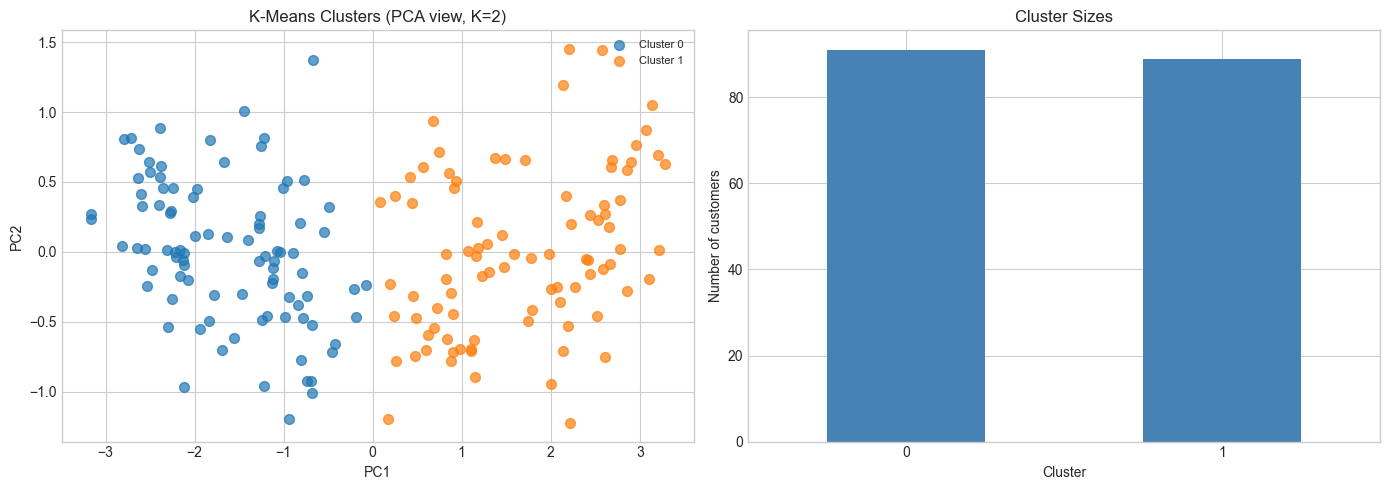

PCA explained variance: 92.20% of total variance


In [91]:
# Step 7) Visualization — PCA 2D projection + cluster sizes

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)  # Project 4D → 2D for plotting

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = [plt.cm.tab10(i % 10) for i in range(best_k)]
for c in range(best_k):
    mask = cluster_labels == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=[palette[c]], label=f'Cluster {c}', alpha=0.7, s=50)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title(f'K-Means Clusters (PCA view, K={best_k})')
axes[0].legend(fontsize=8)

dataset['Cluster'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of customers')
axes[1].set_title('Cluster Sizes')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f'PCA explained variance: {pca.explained_variance_ratio_.sum():.2%} of total variance')

## Example 2 — Cell 8: Evaluation

Compute **Inertia** and **Silhouette Score** for the multi-feature clustering.

**What this cell does:** Evaluates cluster quality in 4-dimensional scaled space.

In [92]:
# Step 8) Evaluation

sil_avg = silhouette_score(X_scaled, cluster_labels)

results = pd.DataFrame({
    'Metric': ['Inertia', 'Silhouette Score', 'Number of Clusters', 'Features'],
    'Value': [kmeans.inertia_, sil_avg, best_k, len(FEATURE_COLS)],
    'Description': [
        'Within-cluster sum of squared distances',
        'Overall cluster separation quality',
        'K chosen by silhouette',
        'Number of input features'
    ]
})

display(results.round(4))

print(f'\nExample 2 Silhouette Score = {sil_avg:.4f}')

,Metric,Value,Description
0,Inertia,236.5502,Within-cluster sum of squared distances
1,Silhouette Score,0.5403,Overall cluster separation quality
2,Number of Clusters,2.0000,K chosen by silhouette
3,Features,4.0000,Number of input features



Example 2 Silhouette Score = 0.5403


## Why does K-Means work for Customer Segments?

| # | Reason | Explanation |
|---|--------|-------------|
| 1 | **Multiple features** | Income, spending, age, and purchases define distinct lifestyles |
| 2 | **Cluster profiles** | Mean per cluster gives actionable business segments |
| 3 | **PCA visualization** | Projects 4D clusters into 2D for plotting |
| 4 | **Scaling essential** | Income (~60k) vs Num_Purchases (~5) — must standardize |
| 5 | **Silhouette tuning** | Picks K that maximizes cluster separation |

> **Use case:** Marketing teams label clusters (e.g. "Premium", "Budget") based on profile tables.

## Understanding Clustering Metrics — Example 2

| Silhouette | Interpretation |
|------------|----------------|
| **> 0.7** | Strong, well-separated clusters |
| **0.5 – 0.7** | Reasonable structure |
| **0.25 – 0.5** | Weak but usable |
| **< 0.25** | Poor clustering — try different K or algorithm |

> **Limitation:** K-Means assumes **spherical** clusters — if segments are elongated, try **DBSCAN** or **GMM**.